# RMP Stellarator Resonance Analysis

This notebook is the main public workflow for analytic stellarator resonance geometry.  It folds two formerly separate text-only tutorials into one visual computation:

1. Build an analytic stellarator equilibrium and trace Poincare sections.
2. Compute resonant RMP Fourier components and their analytic X/O fixed points.
3. Promote raw section points into geometry: crossings, fixed-point markers, resonant surfaces, local stable branches, and coordinate overlays.
4. Compare unperturbed and perturbed sections with a PEST-style grid.
5. Summarize island widths, Chirikov overlap, and the $(m,n)$ spectrum.
6. Produce a modern multi-section figure using `pyna.plot` helpers.

The notebook is designed to be executed locally before publishing the docs.  GitHub Pages renders the saved outputs rather than recomputing field-line traces.


## [SETUP] Imports and publication style

In [1]:
import sys
import json
import pathlib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

PROJECT_ROOT = None
for candidate in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (candidate / 'pyna').is_dir() and (candidate / 'pyproject.toml').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is not None and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'figure.dpi': 150,
    'text.usetex': False,
    'axes.linewidth': 0.75,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

from pyna.toroidal.equilibrium.stellarator import simple_stellarator
from pyna.toroidal.perturbation_spectrum import radial_perturbation_Fourier_spectrum
from pyna.toroidal.torus_deformation import fieldline_deformation_spectrum
from pyna.toroidal.visual.RMP_spectrum import (
    find_resonant_components_analytic,
    compare_cyna_fixed_points_for_component,
    deformed_circular_section_rz,
    project_fixed_points_to_deformed_surface,
    compute_mn_spectrum,
    plot_mn_heatmap,
    ISLAND_CMAPS,
)
from pyna.topo.poincare import poincare_from_fieldlines, ToroidalSection
from pyna.fields.cylindrical import VectorFieldCylind
from pyna.plot import (
    draw_pest_grid,
    draw_poincare_points,
    draw_rmp_resonance_section,
    plot_rmp_resonance_sections,
)

print('Setup complete. numpy', np.__version__, '  matplotlib', matplotlib.__version__)


Setup complete. numpy 2.4.6   matplotlib 3.11.0


## [EQ] Build the stellarator equilibrium

We use an analytic single-helicity stellarator with:
- Major radius $R_0 = 3.0$ m, minor radius $r_0 = 0.3$ m, on-axis field $B_0 = 2.5$ T
- Linear $q$-profile: $q_0=1.5$ (axis) → $q_1=4.5$ (LCFS)
- Helical ripple: $(m_h, n_h) = (3,3)$, $\epsilon_h = 0.03$

The safety factor profile $q(\psi) = q_0 + (q_1-q_0)\psi$ spans the range $[1.5, 4.5]$, so resonances at $q = 2/1, 3/1, 4/1$ (among others) lie within the plasma.

In [2]:
eq = simple_stellarator(
    R0=3.0, r0=0.3, B0=2.5,
    q0=1.5, q1=4.5,
    m_h=3, n_h=3, epsilon_h=0.03,
)
print(eq)
print(f'q range: [{eq.q0}, {eq.q1}]')
print(f'Resonant surface for (2,1): psi_res = {eq.resonant_psi(2,1)}')
print(f'Resonant surface for (4,2): psi_res = {eq.resonant_psi(4,2)}')
print(f'Resonant surface for (6,3): psi_res = {eq.resonant_psi(6,3)}')

# Convenience references
R0_eq = eq.R0
r0_eq = eq.r0


StellaratorSimple(R0=3.0 m, r0=0.3 m, B0=2.5 T, q=[1.5, 4.5], m_h=3, n_h=3, ε_h=0.03)
q range: [1.5, 4.5]
Resonant surface for (2,1): psi_res = [0.16666666666666666]
Resonant surface for (4,2): psi_res = [0.16666666666666666]
Resonant surface for (6,3): psi_res = [0.16666666666666666]


## [POINCARE_UNPERTURBED] Unperturbed Poincare section at phi=0

We trace field lines of the unperturbed equilibrium and record crossings at the $\varphi=0$ plane.  The result is the raw sampled geometry: useful, but not yet a topological object.  Later cells add the promotion layer by overlaying resonant surfaces, X/O markers, local stable branches, and a PEST-style coordinate grid.

Crossings are cached to `pyna_output/poincare_unperturbed.json`.


Loaded from cache: 735 crossings


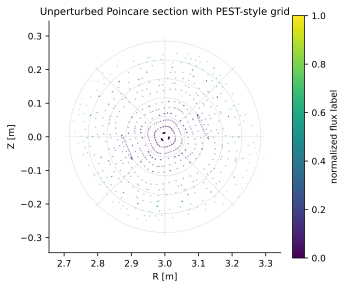

In [3]:
CACHE_UNPERT = pathlib.Path('pyna_output/poincare_unperturbed.json')
CACHE_UNPERT.parent.mkdir(exist_ok=True)

if CACHE_UNPERT.exists():
    _d = json.loads(CACHE_UNPERT.read_text())
    R_cross_u = np.array(_d['R'])
    Z_cross_u = np.array(_d['Z'])
    print(f'Loaded from cache: {len(R_cross_u)} crossings')
else:
    n_fieldlines = 15
    n_turns = 50
    dt = 0.08
    t_max = n_turns * 2 * np.pi * eq.R0

    R_starts = np.linspace(eq.R0 + 0.04*eq.r0, eq.R0 + 0.92*eq.r0, n_fieldlines)
    start_pts = np.zeros((n_fieldlines, 3))
    start_pts[:, 0] = R_starts
    start_pts[:, 2] = 0.0

    sections_u = [ToroidalSection(phi0=0.0)]
    print(f'Tracing {n_fieldlines} field lines x {n_turns} turns (dt={dt}, t_max={t_max:.1f} m)...')

    pmap_u = poincare_from_fieldlines(
        eq.field_func,
        start_pts,
        sections_u,
        t_max=t_max,
        dt=dt,
    )
    arr_u = pmap_u.crossing_array(0)
    R_cross_u = arr_u[:, 0]
    Z_cross_u = arr_u[:, 1]
    print(f'Computed: {len(R_cross_u)} crossings. Caching...')
    CACHE_UNPERT.write_text(json.dumps({'R': R_cross_u.tolist(), 'Z': Z_cross_u.tolist()}))
    print('Cached.')

fig_u, ax_u = plt.subplots(figsize=(4.7, 4.3), constrained_layout=True)
draw_pest_grid(ax_u, eq, alpha=0.22)
psi_pts = np.clip(((R_cross_u - eq.R0)**2 + Z_cross_u**2) / eq.r0**2, 0, 1)
draw_poincare_points(
    ax_u,
    R_cross_u,
    Z_cross_u,
    values=psi_pts,
    cmap='viridis',
    point_size=1.8,
    alpha=0.50,
    rasterized=False,
)
sm_u = plt.cm.ScalarMappable(cmap='viridis', norm=Normalize(0, 1))
fig_u.colorbar(sm_u, ax=ax_u, label='normalized flux label', shrink=0.82)
lim = 1.15 * eq.r0
ax_u.set_xlim(eq.R0 - lim, eq.R0 + lim)
ax_u.set_ylim(-lim, lim)
ax_u.set_aspect('equal')
ax_u.set_xlabel('R [m]')
ax_u.set_ylabel('Z [m]')
ax_u.set_title('Unperturbed Poincare section with PEST-style grid')
plt.show()


## [RMP_FIELD] Define and visualise the RMP perturbation field

We apply a single-mode RMP with base mode $(m, n) = (2, 1)$ and amplitude $\delta B = 1$ mT:

$$\delta B_R(R,Z,\varphi) = B_\mathrm{rmp}\cos(m\theta - n\varphi)\cos\theta$$
$$\delta B_Z(R,Z,\varphi) = B_\mathrm{rmp}\cos(m\theta - n\varphi)\sin\theta$$

where $\theta = \arctan2(Z, R-R_0)$ is the poloidal angle.

We plot the radial perturbation $\delta B_\psi = \delta B_R\cos\theta + \delta B_Z\sin\theta$ on the resonant $q=2$ surface vs $\theta$ at two toroidal angles.

q=2/1 resonant surface: psi=0.167, r=12.2 cm
delta_B/B0 = 0.040%


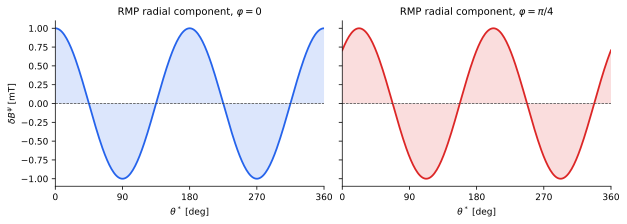

RMP field defined and visualised.


In [4]:
base_m, base_n = 2, 1
B_rmp = 1e-3  # 1 mT

def delta_B_RMP(R, Z, phi, m=base_m, n=base_n, B_amp=B_rmp):
    """Single-mode RMP perturbation field (BR, BZ, Bphi)."""
    theta_pol = np.arctan2(Z, R - R0_eq)
    phase = m * theta_pol - n * phi
    dBR = B_amp * np.cos(phase) * np.cos(theta_pol)
    dBZ = B_amp * np.cos(phase) * np.sin(theta_pol)
    return np.array([dBR, dBZ, np.zeros_like(np.asarray(dBR), dtype=float)])

psi_res_21 = eq.resonant_psi(2, 1)[0]
r_res_21 = np.sqrt(psi_res_21) * eq.r0
print(f'q=2/1 resonant surface: psi={psi_res_21:.3f}, r={r_res_21*100:.1f} cm')
print(f'delta_B/B0 = {B_rmp/eq.B0*100:.3f}%')

theta_arr = np.linspace(0, 2*np.pi, 240)
R_res = eq.R0 + r_res_21 * np.cos(theta_arr)
Z_res = r_res_21 * np.sin(theta_arr)

fig_rmp, axes_rmp = plt.subplots(1, 2, figsize=(8.6, 3.0), sharey=True, constrained_layout=True)
for ax, phi_val, phi_label, color in [
    (axes_rmp[0], 0.0, r'$\varphi=0$', '#2563eb'),
    (axes_rmp[1], np.pi/4, r'$\varphi=\pi/4$', '#dc2626'),
]:
    dBpsi = np.array([
        delta_B_RMP(R_res[i], Z_res[i], phi_val)[0]*np.cos(theta_arr[i])
        + delta_B_RMP(R_res[i], Z_res[i], phi_val)[1]*np.sin(theta_arr[i])
        for i in range(len(theta_arr))
    ])
    ax.plot(np.degrees(theta_arr), dBpsi * 1e3, color=color, linewidth=1.8)
    ax.fill_between(np.degrees(theta_arr), 0, dBpsi * 1e3, color=color, alpha=0.16, linewidth=0)
    ax.axhline(0, color='0.25', lw=0.7, linestyle='--')
    ax.set_xlabel(r'$\theta^*$ [deg]')
    ax.set_title(f'RMP radial component, {phi_label}')
    ax.set_xlim(0, 360)
    ax.set_xticks([0, 90, 180, 270, 360])
axes_rmp[0].set_ylabel(r'$\delta B^\psi$ [mT]')
plt.show()
print('RMP field defined and visualised.')


## [RESONANT_COMPONENTS] Find resonant Fourier components

We decompose the RMP field on each resonant flux surface using a 2D FFT and extract the amplitudes of the resonant $(m_k, n_k) = k\times(2,1)$ harmonics. The **island half-width** is given by the Rutherford formula:

$$w_\psi = 4\sqrt{\frac{|b_{mn}|}{m|\partial q/\partial\psi|}}$$

Results are cached to `pyna_output/rmp_components.json`.

In [5]:
CACHE_COMP = pathlib.Path('pyna_output/rmp_components.json')
CACHE_COMP.parent.mkdir(exist_ok=True)

print('Computing resonant components (n_theta=32, n_phi=16)...')
components = find_resonant_components_analytic(
    eq, delta_B_RMP, base_m=base_m, base_n=base_n,
    max_harmonic=3, n_theta=32, n_phi=16,
)
print(f'Found {len(components)} resonant components.')

# Cache as JSON
_comp_data = [{
    'm': c.m, 'n': c.n, 'harmonic_order': c.harmonic_order,
    'b_mn_real': float(c.b_mn.real), 'b_mn_imag': float(c.b_mn.imag),
    'psi_res': float(c.psi_res), 'q_res': float(c.q_res),
    'half_width_psi': float(c.half_width_psi),
    'half_width_r': float(c.half_width_r),
    'opoint_theta': float(c.opoint_theta),
    'xpoint_theta': float(c.xpoint_theta),
    'q_prime_sign': int(c.q_prime_sign),
} for c in components]
CACHE_COMP.write_text(json.dumps(_comp_data, indent=2))
print('Cached to', CACHE_COMP)

# Print table
print()
print(f'{"k":>3}  {"(m,n)":>8}  {"psi_res":>8}  {"q_res":>6}  {"b_mn|":>10}  {"w_psi":>8}  {"w_r (cm)":>10}  {"theta_O":>8}  {"theta_X":>8}')
print('-'*80)
for c in components:
    print(f'{c.harmonic_order:>3}  ({c.m},{c.n}){"":>4}  {c.psi_res:>8.4f}  {c.q_res:>6.3f}  {abs(c.b_mn):>10.3e}  {c.half_width_psi:>8.4f}  {c.half_width_r*100:>10.2f}  {np.degrees(c.opoint_theta):>8.1f}  {np.degrees(c.xpoint_theta):>8.1f}')


Computing resonant components (n_theta=32, n_phi=16)...
  k=1: (2,1) ψ_res=0.167 q_res=2.000 |b_mn|=5.000e-04 phase_arg=0.0° w_ψ=0.0365 (1.34 cm) θ_O=135.0° θ_X=45.0°
  k=2: (4,2) — |b_mn|=3.52e-21 below threshold
  k=3: (6,3) — |b_mn|=2.10e-20 below threshold
Found 1 resonant components.
Cached to pyna_output/rmp_components.json

  k     (m,n)   psi_res   q_res       b_mn|     w_psi    w_r (cm)   theta_O   theta_X
--------------------------------------------------------------------------------
  1  (2,1)        0.1667   2.000   5.000e-04    0.0365        1.34     135.0      45.0


## [POINCARE_PERTURBED] Geometry promotion: crossings -> X/O points -> manifolds

The perturbed trace gives sampled Poincare points.  The analytic RMP spectrum gives fixed-point predictions.  `pyna.plot.draw_rmp_resonance_section` combines them into one section geometry:

- Poincare points colored by flux label;
- PEST-style $(S,\theta^*)$ grid lines;
- resonant surfaces for each harmonic;
- O-points and X-points from the analytic fixed-point formula;
- local stable separatrix branches born from the X-points.

This is the same promotion idea used by the general geometry workflow: raw samples are kept distinct from persistent geometric objects and overlays until an explicit model or diagnostic justifies the promotion.


Loaded perturbed Poincare from cache (6 sections).
phi=0 section: 735 crossings


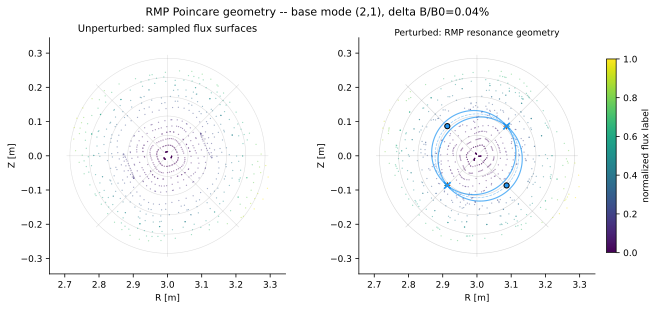

In [6]:
# Perturbed field_func
# --------------------
def field_func_perturbed(rzphi_1d):
    """Unit-tangent dRZphi/ds for the field-line ODE with RMP added."""
    rzphi_1d = np.asarray(rzphi_1d, dtype=float)
    R, Z, phi = rzphi_1d[0], rzphi_1d[1], rzphi_1d[2]
    theta = np.arctan2(Z, R - R0_eq)
    psi = eq.psi_ax(R, Z)
    q = float(eq.q_of_psi(psi))
    r_minor = np.sqrt((R - R0_eq)**2 + Z**2)
    B_phi = eq.B0 * eq.R0 / R
    B_pol = B_phi * r_minor / (R * max(abs(q), 1e-3))
    if r_minor > 1e-10:
        BR0 = -B_pol * np.sin(theta)
        BZ0 =  B_pol * np.cos(theta)
    else:
        BR0 = BZ0 = 0.0
    delta_BR_eq = eq.epsilon_h * eq.B0 * psi * np.cos(eq.m_h * theta - eq.n_h * phi)
    db = delta_B_RMP(R, Z, phi)
    BR_tot = BR0 + delta_BR_eq + db[0]
    BZ_tot = BZ0 + db[1]
    B_mag = np.sqrt(BR_tot**2 + BZ_tot**2 + B_phi**2) + 1e-30
    return np.array([BR_tot/B_mag, BZ_tot/B_mag, B_phi/(R*B_mag)])

CACHE_PERT = pathlib.Path('pyna_output/poincare_perturbed.json')
CACHE_PERT.parent.mkdir(exist_ok=True)

phi_sections_deg = [0, 60, 120, 180, 240, 300]
phi_sections = np.array(phi_sections_deg) * np.pi / 180.0

if CACHE_PERT.exists():
    _d = json.loads(CACHE_PERT.read_text())
    all_sections_data = _d['sections']
    print(f'Loaded perturbed Poincare from cache ({len(all_sections_data)} sections).')
else:
    n_fieldlines = 15
    n_turns = 50
    dt = 0.08
    t_max = n_turns * 2 * np.pi * eq.R0

    R_starts = np.linspace(eq.R0 + 0.04*eq.r0, eq.R0 + 0.92*eq.r0, n_fieldlines)
    start_pts = np.zeros((n_fieldlines, 3))
    start_pts[:, 0] = R_starts

    sections_p = [ToroidalSection(phi0=ph) for ph in phi_sections]
    print(f'Tracing {n_fieldlines} field lines x {n_turns} turns (t_max={t_max:.1f} m)...')

    pmap_p = poincare_from_fieldlines(
        field_func_perturbed,
        start_pts,
        sections_p,
        t_max=t_max,
        dt=dt,
    )

    all_sections_data = []
    for i_sec in range(len(sections_p)):
        arr = pmap_p.crossing_array(i_sec)
        print(f'  phi={phi_sections_deg[i_sec]} deg: {len(arr)} crossings')
        all_sections_data.append({
            'R': arr[:, 0].tolist() if len(arr) else [],
            'Z': arr[:, 1].tolist() if len(arr) else [],
        })

    CACHE_PERT.write_text(json.dumps({
        'phi_sections_deg': phi_sections_deg,
        'sections': all_sections_data,
    }))
    print('Computed and cached.')

R_cross_p0 = np.array(all_sections_data[0]['R'])
Z_cross_p0 = np.array(all_sections_data[0]['Z'])
print(f'phi=0 section: {len(R_cross_p0)} crossings')

fig2, (axL, axR) = plt.subplots(1, 2, figsize=(9.4, 4.2), constrained_layout=True)

# Left: raw unperturbed sample geometry.
draw_pest_grid(axL, eq, alpha=0.22)
psi_u = np.clip(((R_cross_u - eq.R0)**2 + Z_cross_u**2) / eq.r0**2, 0, 1)
draw_poincare_points(axL, R_cross_u, Z_cross_u, values=psi_u, cmap='viridis', point_size=1.8, alpha=0.46, rasterized=False)
lim = 1.15 * eq.r0
axL.set_xlim(eq.R0 - lim, eq.R0 + lim)
axL.set_ylim(-lim, lim)
axL.set_aspect('equal')
axL.set_xlabel('R [m]')
axL.set_ylabel('Z [m]')
axL.set_title('Unperturbed: sampled flux surfaces')

# Right: promoted resonance geometry with X/O points and local stable branches.
draw_rmp_resonance_section(
    axR,
    R_cross_p0,
    Z_cross_p0,
    eq=eq,
    components=components,
    phi=0.0,
    colors=ISLAND_CMAPS,
    title='Perturbed: RMP resonance geometry',
    point_size=1.8,
    point_alpha=0.46,
)

sm2 = plt.cm.ScalarMappable(cmap='viridis', norm=Normalize(0, 1))
fig2.colorbar(sm2, ax=[axL, axR], label='normalized flux label', shrink=0.82, pad=0.02)
fig2.suptitle(
    f'RMP Poincare geometry -- base mode ({base_m},{base_n}), '
    f'delta B/B0={B_rmp/eq.B0*100:.2f}%',
    fontsize=11,
)
plt.show()


## [CYNA_FIXED_POINTS] Newton fixed points versus RMP spectrum phases

The RMP spectrum predicts first-order O/X-point phases. Here we use the accelerated `cyna` Newton map to refine those seeds into true periodic-orbit fixed points, then measure the phase error. The RMP-only case is a code sanity check; adding the analytic helical ripple shows the finite-amplitude/model shift that the first-order spectrum intentionally ignores.


Building cyna field: RMP only


Building cyna field: RMP + analytic helical ripple

case                           kind branch    theta*   theta_N     dtheta    m*dtheta     dr [cm]    residual
-------------------------------------------------------------------------------------------------------------
RMP only                        O/O      0   315.000   315.001     0.0011      0.0022     -0.0059     3.3e-13
RMP only                        O/O      1   135.000   134.999    -0.0012     -0.0024     -0.0064     8.9e-13
RMP only                        X/X      0    45.000    44.999    -0.0011     -0.0023     -0.0066     8.7e-12
RMP only                        X/X      1   225.000   225.001     0.0012      0.0025     -0.0070     8.0e-15
  -> RMP only: max |dtheta|=0.0012 deg, max |m*dtheta|=0.0025 deg
RMP + analytic helical ripple   O/O      0   315.000   318.598     3.5983      7.1965      0.9476     9.4e-15
RMP + analytic helical ripple   O/O      1   135.000   138.312     3.3121      6.6242      0.9206     5.7e-15
RM

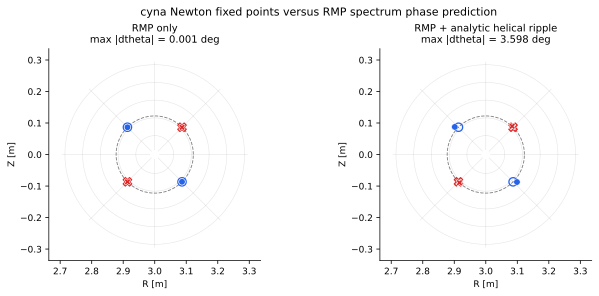

In [ ]:
# Build a physical cylindrical field for cyna and compare Newton fixed points.
def sample_cyna_field(eq_case, nR=128, nPhi=128, lim_factor=1.18):
    lim = lim_factor * eq_case.r0
    R_grid = np.linspace(eq_case.R0 - lim, eq_case.R0 + lim, nR)
    Z_grid = np.linspace(-lim, lim, nR)
    Phi_grid = np.linspace(0.0, 2*np.pi, nPhi, endpoint=False)
    RR, ZZ, PP = np.meshgrid(R_grid, Z_grid, Phi_grid, indexing='ij')

    theta = np.arctan2(ZZ, RR - eq_case.R0)
    psi = eq_case.psi_ax(RR, ZZ)
    q = eq_case.q_of_psi(psi)
    r_minor = np.hypot(RR - eq_case.R0, ZZ)
    B_phi = eq_case.B0 * eq_case.R0 / RR
    B_pol = B_phi * r_minor / (RR * np.maximum(np.abs(q), 1e-3))
    BR0 = np.where(r_minor > 1e-10, -B_pol * np.sin(theta), 0.0)
    BZ0 = np.where(r_minor > 1e-10,  B_pol * np.cos(theta), 0.0)
    delta_BR_eq = eq_case.epsilon_h * eq_case.B0 * psi * np.cos(eq_case.m_h * theta - eq_case.n_h * PP)
    db = delta_B_RMP(RR, ZZ, PP)

    return VectorFieldCylind(
        R_grid, Z_grid, Phi_grid,
        BR=BR0 + delta_BR_eq + db[0],
        BZ=BZ0 + db[1],
        BPhi=B_phi + db[2],
        label='analytic_rmp_for_cyna',
    )


def row_newton_theta_deg(row, eq_case):
    axis_R, axis_Z = eq_case.magnetic_axis
    theta = np.arctan2(row.newton_Z - axis_Z, row.newton_R - axis_R) % (2*np.pi)
    return float(np.degrees(theta))


cyna_rows_by_case = {}
cyna_eq_by_case = {}
if components:
    eq_rmp_only = simple_stellarator(
        R0=eq.R0, r0=eq.r0, B0=eq.B0,
        q0=eq.q0, q1=eq.q1,
        m_h=eq.m_h, n_h=eq.n_h, epsilon_h=0.0,
    )
    try:
        for case_label, eq_case in [
            ('RMP only', eq_rmp_only),
            ('RMP + analytic helical ripple', eq),
        ]:
            print(f'Building cyna field: {case_label}')
            field_case = sample_cyna_field(eq_case)
            rows = compare_cyna_fixed_points_for_component(
                field_case,
                components[0],
                eq_case,
                DPhi=0.015,
                max_iter=80,
                tol=1e-11,
                n_threads=4,
            )
            cyna_rows_by_case[case_label] = rows
            cyna_eq_by_case[case_label] = eq_case
    except ImportError as exc:
        print('cyna fixed-point comparison skipped:', exc)

if cyna_rows_by_case:
    print()
    header = '{:<30} {:>4} {:>6} {:>9} {:>9} {:>10} {:>11} {:>11} {:>11}'.format(
        'case', 'kind', 'branch', 'theta*', 'theta_N', 'dtheta', 'm*dtheta', 'dr [cm]', 'residual'
    )
    print(header)
    print('-' * len(header))
    for case_label, rows in cyna_rows_by_case.items():
        eq_case = cyna_eq_by_case[case_label]
        for row in rows:
            theta_n = row_newton_theta_deg(row, eq_case)
            print('{:<30} {:>4} {:>6d} {:>9.3f} {:>9.3f} {:>10.4f} {:>11.4f} {:>11.4f} {:>11.1e}'.format(
                case_label,
                row.predicted_kind + '/' + (row.newton_kind or '?'),
                row.branch,
                row.predicted_theta_deg,
                theta_n,
                row.theta_error_deg,
                row.helical_phase_error_deg,
                row.radial_error_cm,
                row.residual,
            ))
        max_dtheta = max(abs(row.theta_error_deg) for row in rows)
        max_helical = max(abs(row.helical_phase_error_deg) for row in rows)
        print(f'  -> {case_label}: max |dtheta|={max_dtheta:.4f} deg, max |m*dtheta|={max_helical:.4f} deg')

if cyna_rows_by_case:
    fig_cmp, axes_cmp = plt.subplots(1, len(cyna_rows_by_case), figsize=(9.2, 4.0), constrained_layout=True)
    axes_cmp = np.atleast_1d(axes_cmp)
    for ax, (case_label, rows) in zip(axes_cmp, cyna_rows_by_case.items()):
        eq_case = cyna_eq_by_case[case_label]
        draw_pest_grid(ax, eq_case, alpha=0.18)
        r_res = np.sqrt(components[0].psi_res) * eq_case.r0
        theta_ring = np.linspace(0, 2*np.pi, 361)
        ax.plot(eq_case.R0 + r_res*np.cos(theta_ring), r_res*np.sin(theta_ring),
                color='0.25', lw=0.9, ls='--', alpha=0.65)
        for row in rows:
            color = '#2563eb' if row.predicted_kind == 'O' else '#dc2626'
            marker = 'o' if row.predicted_kind == 'O' else 'X'
            ax.plot([row.predicted_R, row.newton_R], [row.predicted_Z, row.newton_Z],
                    color=color, lw=1.0, alpha=0.65)
            ax.scatter(row.predicted_R, row.predicted_Z, marker=marker, s=70,
                       facecolors='none', edgecolors=color, linewidths=1.3, zorder=5)
            ax.scatter(row.newton_R, row.newton_Z, marker=marker, s=42,
                       color=color, edgecolors='white', linewidths=0.5, zorder=6)
        lim = 1.12 * eq_case.r0
        ax.set_xlim(eq_case.R0 - lim, eq_case.R0 + lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.set_xlabel('R [m]')
        ax.set_ylabel('Z [m]')
        max_dtheta = max(abs(row.theta_error_deg) for row in rows)
        ax.set_title(f'{case_label}\nmax |dtheta| = {max_dtheta:.3f} deg')
    fig_cmp.suptitle('cyna Newton fixed points versus RMP spectrum phase prediction', fontsize=11)
    plt.show()


## [NONRESONANT_DEFORMATION] Non-resonant ripple as flux-surface deformation

The helical ripple in this analytic equilibrium is not the resonant RMP component that opens the `(m,n)=(2,1)` island. It still changes the geometry of the nearby flux surface. If we compare Newton fixed points against the undeformed circular surface, that smooth displacement appears as an artificial phase error.

Here we sample the helical-ripple contribution to the field-line ODE,
$$\frac{dr}{d\phi}=F_r(\theta,\phi), \qquad \frac{d\theta}{d\phi}=\iota+F_\theta(\theta,\phi),$$
Fourier transform `F_r` and `F_theta`, solve the non-resonant homological equation, and project the cyna fixed points onto the deformed section. The remaining mismatch is the part not explained by smooth surface deformation.

Raw circular-surface max |dtheta|:       3.5983 deg
Deformed-surface-coordinate max |dtheta|: 1.1108 deg
Max Newton-to-deformed-section distance:  0.570 cm

kind branch   raw dtheta  deformed dtheta distance [cm]
-------------------------------------------------------
O         0       3.5983           0.3990         0.570
O         1       3.3121           0.4865         0.527
X         0       2.0899          -1.1108         0.478
X         1       1.8776          -0.9774         0.423


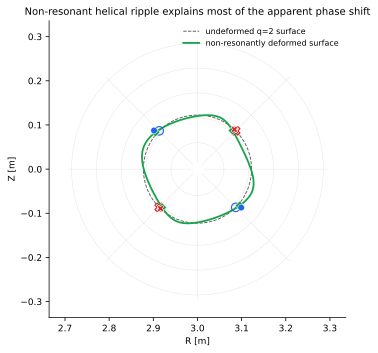

In [8]:
def helical_velocity_deformation(eq_case, psi_res, n_theta=256, n_phi=256, include_shear=False):
    r_res = np.sqrt(psi_res) * eq_case.r0
    iota = 1.0 / float(eq_case.q_of_psi(psi_res))
    theta = np.linspace(0.0, 2*np.pi, n_theta, endpoint=False)
    phi = np.linspace(0.0, 2*np.pi, n_phi, endpoint=False)
    TT, PP = np.meshgrid(theta, phi, indexing='xy')
    RR = eq_case.R0 + r_res * np.cos(TT)
    ZZ = r_res * np.sin(TT)
    Bphi = eq_case.B0 * eq_case.R0 / RR
    delta_BR = eq_case.epsilon_h * eq_case.B0 * eq_case.psi_ax(RR, ZZ) * np.cos(
        eq_case.m_h * TT - eq_case.n_h * PP
    )

    radial_velocity = RR * delta_BR * np.cos(TT) / Bphi
    poloidal_velocity = -RR * delta_BR * np.sin(TT) / (r_res * Bphi)
    radial_spec = radial_perturbation_Fourier_spectrum(
        radial_velocity, theta, phi, m_max=8, n_max=8, min_amplitude=1e-12
    )
    poloidal_spec = radial_perturbation_Fourier_spectrum(
        poloidal_velocity, theta, phi, m_max=8, n_max=8, min_amplitude=1e-12
    )
    poloidal_coeffs = np.array([
        poloidal_spec.mode_coefficient(int(m), int(n))
        for m, n in zip(radial_spec.m, radial_spec.n)
    ])
    nonresonant = np.abs(radial_spec.m * iota + radial_spec.n) > 1e-9
    q_res = float(eq_case.q_of_psi(psi_res))
    iota_prime = -(eq_case.q1 - eq_case.q0) * (2.0 * r_res / eq_case.r0**2) / q_res**2
    deformation = fieldline_deformation_spectrum(
        radial_spec.m[nonresonant],
        radial_spec.n[nonresonant],
        radial_spec.dBr[nonresonant],
        poloidal_coeffs[nonresonant],
        iota=iota,
        iota_prime=iota_prime,
        include_shear=include_shear,
    )
    return deformation, r_res


case_label = 'RMP + analytic helical ripple'
if components and case_label in cyna_rows_by_case:
    rows = cyna_rows_by_case[case_label]
    eq_case = cyna_eq_by_case[case_label]
    deformation, r_res = helical_velocity_deformation(eq_case, components[0].psi_res)
    projected_rows = project_fixed_points_to_deformed_surface(
        rows,
        eq_case,
        deformation,
        r_minor=r_res,
        theta_window=0.35,
    )

    raw_max = max(abs(row.theta_error_deg) for row in rows)
    corrected_max = max(abs(row.theta_error_deg) for row in projected_rows)
    nearest_max = max(row.distance_cm for row in projected_rows)
    print(f'Raw circular-surface max |dtheta|:       {raw_max:.4f} deg')
    print(f'Deformed-surface-coordinate max |dtheta|: {corrected_max:.4f} deg')
    print(f'Max Newton-to-deformed-section distance:  {nearest_max:.3f} cm')
    print()
    header = '{:<4} {:>6} {:>12} {:>16} {:>13}'.format(
        'kind', 'branch', 'raw dtheta', 'deformed dtheta', 'distance [cm]'
    )
    print(header)
    print('-' * len(header))
    for row, proj in zip(rows, projected_rows):
        print('{:<4} {:>6d} {:>12.4f} {:>16.4f} {:>13.3f}'.format(
            row.predicted_kind,
            row.branch,
            row.theta_error_deg,
            proj.theta_error_deg,
            proj.distance_cm,
        ))

    theta_line = np.linspace(0.0, 2*np.pi, 721)
    R_circ = eq_case.R0 + r_res*np.cos(theta_line)
    Z_circ = r_res*np.sin(theta_line)
    R_def, Z_def = deformed_circular_section_rz(eq_case, r_res, deformation, theta_line)

    fig_def, ax_def = plt.subplots(figsize=(5.2, 4.8), constrained_layout=True)
    draw_pest_grid(ax_def, eq_case, alpha=0.16)
    ax_def.plot(R_circ, Z_circ, color='0.35', lw=0.9, ls='--', label='undeformed q=2 surface')
    ax_def.plot(R_def, Z_def, color='#16a34a', lw=1.8, label='non-resonantly deformed surface')

    for row, proj in zip(rows, projected_rows):
        color = '#2563eb' if row.predicted_kind == 'O' else '#dc2626'
        marker = 'o' if row.predicted_kind == 'O' else 'X'
        ax_def.plot([row.predicted_R, row.newton_R], [row.predicted_Z, row.newton_Z],
                    color=color, lw=0.8, alpha=0.35)
        ax_def.plot([proj.closest_R, row.newton_R], [proj.closest_Z, row.newton_Z],
                    color=color, lw=1.1, ls=':', alpha=0.9)
        ax_def.scatter(row.predicted_R, row.predicted_Z, marker=marker, s=72,
                       facecolors='none', edgecolors=color, linewidths=1.2, zorder=5)
        ax_def.scatter(proj.closest_R, proj.closest_Z, marker='D', s=42,
                       color='#16a34a', edgecolors='white', linewidths=0.45, zorder=6)
        ax_def.scatter(row.newton_R, row.newton_Z, marker=marker, s=44,
                       color=color, edgecolors='white', linewidths=0.5, zorder=7)

    lim = 1.12 * eq_case.r0
    ax_def.set_xlim(eq_case.R0 - lim, eq_case.R0 + lim)
    ax_def.set_ylim(-lim, lim)
    ax_def.set_aspect('equal')
    ax_def.set_xlabel('R [m]')
    ax_def.set_ylabel('Z [m]')
    ax_def.set_title('Non-resonant helical ripple explains most of the apparent phase shift')
    ax_def.legend(frameon=False, loc='upper right', fontsize=8)
    plt.show()
else:
    print('Non-resonant deformation check skipped because cyna rows are unavailable.')

## [ORDER_ANALYSIS] Perturbation-order checks

First-order formulas are useful only if their residuals scale as the next neglected order. We check three separate claims on the same simple case:

- a non-resonant helical ripple corrected with the shear-aware first-order deformation leaves an invariant-torus map residual with slope near `2`;
- the resonant RMP coefficient is linear in the perturbation amplitude, while the island half-width scales as `|delta B|^{1/2}` and the X/O phase is amplitude-invariant;
- in the coupled field, the linear superposition of the RMP phase prediction and the non-resonant surface deformation reduces the fixed-point position error, but the remaining error includes coupling terms and should not be interpreted as a pure one-parameter order law.

Non-resonant deformation residual slope: k = 1.999 (expected 2)
Resonant coefficient slope:             k = 1.000 (expected 1)
Island half-width slope:                k = 0.500 (expected 0.5)
X/O phase span over amplitude sweep:    0.000e+00 deg



Coupled RMP + helical ripple, fixed RMP amplitude:
epsilon_h     raw [cm]  superposed [cm]     nearest [cm]
    0.000       0.0070           0.0070           0.0070
    0.005       0.1245           0.0093           0.0079
    0.010       0.2770           0.0532           0.0481
    0.020       0.6759           0.2450           0.2165
    0.030       1.2390           0.6083           0.5185


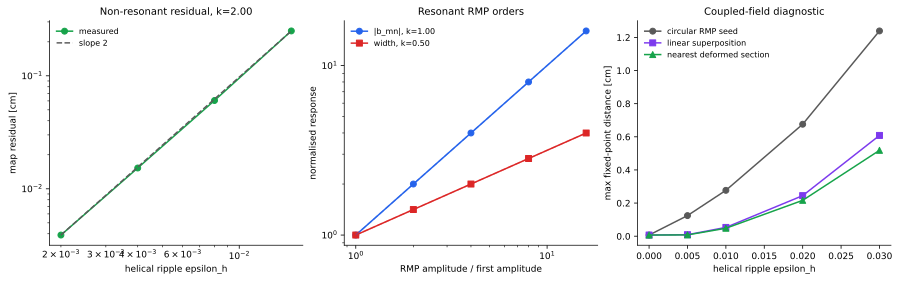

In [9]:
from contextlib import redirect_stdout
import io
from scipy.integrate import solve_ivp


def log_slope(x, y):
    return float(np.polyfit(np.log(np.asarray(x, dtype=float)), np.log(np.asarray(y, dtype=float)), 1)[0])


def deformed_torus_map_residual(epsilon_h, n_alpha=12):
    eq_case = simple_stellarator(
        R0=eq.R0, r0=eq.r0, B0=eq.B0,
        q0=eq.q0, q1=eq.q1,
        m_h=eq.m_h, n_h=eq.n_h, epsilon_h=float(epsilon_h),
    )
    psi_res = eq_case.resonant_psi(base_m, base_n)[0]
    deformation, r_res = helical_velocity_deformation(
        eq_case, psi_res, n_theta=128, n_phi=128, include_shear=True
    )
    iota = 1.0 / float(eq_case.q_of_psi(psi_res))

    def surface(alpha, phi):
        alpha_arr = np.asarray(alpha)
        radius = r_res + deformation.section_r(alpha_arr, phi)
        theta = alpha_arr + deformation.section_theta(alpha_arr, phi)
        return radius, theta

    def rhs(phi, state):
        radius, theta = state
        R = eq_case.R0 + radius*np.cos(theta)
        psi_here = (radius / eq_case.r0)**2
        q_here = float(eq_case.q_of_psi(psi_here))
        Bphi = eq_case.B0 * eq_case.R0 / R
        delta_BR = eq_case.epsilon_h * eq_case.B0 * psi_here * np.cos(
            eq_case.m_h * theta - eq_case.n_h * phi
        )
        return [
            R * delta_BR * np.cos(theta) / Bphi,
            1.0/q_here - R * delta_BR * np.sin(theta) / (radius * Bphi),
        ]

    residuals = []
    for alpha0 in np.linspace(0.0, 2*np.pi, n_alpha, endpoint=False):
        radius0, theta0 = surface(alpha0, 0.0)
        sol = solve_ivp(
            rhs,
            (0.0, 2*np.pi),
            [float(radius0), float(theta0)],
            method='DOP853',
            rtol=5e-10,
            atol=1e-12,
        )
        radius_end, theta_end = sol.y[:, -1]
        radius_pred, theta_pred = surface(alpha0 + iota*2*np.pi, 2*np.pi)
        R_end = eq_case.R0 + radius_end*np.cos(theta_end)
        Z_end = radius_end*np.sin(theta_end)
        R_pred = eq_case.R0 + float(radius_pred)*np.cos(float(theta_pred))
        Z_pred = float(radius_pred)*np.sin(float(theta_pred))
        residuals.append(np.hypot(R_end - R_pred, Z_end - Z_pred))
    return max(residuals)


nonres_eps = np.array([0.002, 0.004, 0.008, 0.016])
nonresidual = np.array([deformed_torus_map_residual(eps_h) for eps_h in nonres_eps])
nonres_slope = log_slope(nonres_eps, nonresidual)

rmp_amplitudes = np.array([2.5e-4, 5e-4, 1e-3, 2e-3, 4e-3])
rmp_b = []
rmp_width = []
rmp_phase = []
for amplitude in rmp_amplitudes:
    def scaled_delta_B_RMP(R, Z, phi, amplitude=amplitude):
        theta = np.arctan2(Z, R - eq.R0)
        phase = base_m * theta - base_n * phi
        return np.array([
            amplitude * np.cos(phase) * np.cos(theta),
            amplitude * np.cos(phase) * np.sin(theta),
            np.zeros_like(np.asarray(theta)),
        ])

    with redirect_stdout(io.StringIO()):
        comp_amp = find_resonant_components_analytic(
            eq,
            scaled_delta_B_RMP,
            base_m=base_m,
            base_n=base_n,
            max_harmonic=1,
            n_theta=64,
            n_phi=32,
            min_amplitude=1e-14,
        )[0]
    rmp_b.append(abs(comp_amp.b_mn))
    rmp_width.append(comp_amp.half_width_r)
    rmp_phase.append(comp_amp.opoint_theta)

rmp_b = np.asarray(rmp_b)
rmp_width = np.asarray(rmp_width)
rmp_phase = np.unwrap(np.asarray(rmp_phase))
b_slope = log_slope(rmp_amplitudes, rmp_b)
width_slope = log_slope(rmp_amplitudes, rmp_width)
phase_span_deg = float(np.degrees(np.ptp(rmp_phase)))

print(f'Non-resonant deformation residual slope: k = {nonres_slope:.3f} (expected 2)')
print(f'Resonant coefficient slope:             k = {b_slope:.3f} (expected 1)')
print(f'Island half-width slope:                k = {width_slope:.3f} (expected 0.5)')
print(f'X/O phase span over amplitude sweep:    {phase_span_deg:.3e} deg')

coupling_rows = []
if components:
    coupling_eps = np.array([0.0, 0.005, 0.01, 0.02, 0.03])
    component = components[0]
    try:
        for eps_h in coupling_eps:
            eq_case = simple_stellarator(
                R0=eq.R0, r0=eq.r0, B0=eq.B0,
                q0=eq.q0, q1=eq.q1,
                m_h=eq.m_h, n_h=eq.n_h, epsilon_h=float(eps_h),
            )
            rows = compare_cyna_fixed_points_for_component(
                sample_cyna_field(eq_case),
                component,
                eq_case,
                DPhi=0.015,
                max_iter=80,
                tol=1e-11,
                n_threads=4,
            )
            raw_cm = max(
                np.hypot(row.newton_R - row.predicted_R, row.newton_Z - row.predicted_Z)
                for row in rows
            ) * 100.0
            if eps_h == 0.0:
                superposed_cm = raw_cm
                nearest_cm = raw_cm
            else:
                deformation, r_res = helical_velocity_deformation(
                    eq_case, component.psi_res, include_shear=True
                )
                superposed_cm = max(
                    np.hypot(
                        float(deformed_circular_section_rz(eq_case, r_res, deformation, row.predicted_theta)[0]) - row.newton_R,
                        float(deformed_circular_section_rz(eq_case, r_res, deformation, row.predicted_theta)[1]) - row.newton_Z,
                    )
                    for row in rows
                ) * 100.0
                projected = project_fixed_points_to_deformed_surface(
                    rows, eq_case, deformation, r_minor=r_res
                )
                nearest_cm = max(row.distance_cm for row in projected)
            coupling_rows.append((eps_h, raw_cm, superposed_cm, nearest_cm))
    except ImportError as exc:
        print('Coupled cyna sweep skipped:', exc)

if coupling_rows:
    print()
    print('Coupled RMP + helical ripple, fixed RMP amplitude:')
    print('{:>9} {:>12} {:>16} {:>16}'.format('epsilon_h', 'raw [cm]', 'superposed [cm]', 'nearest [cm]'))
    for eps_h, raw_cm, superposed_cm, nearest_cm in coupling_rows:
        print(f'{eps_h:9.3f} {raw_cm:12.4f} {superposed_cm:16.4f} {nearest_cm:16.4f}')

fig_order, axes_order = plt.subplots(1, 3, figsize=(12.4, 3.8), constrained_layout=True)

ax = axes_order[0]
ax.loglog(nonres_eps, nonresidual*100, 'o-', color='#16a34a', label='measured')
ref = nonresidual[0] * (nonres_eps/nonres_eps[0])**2
ax.loglog(nonres_eps, ref*100, '--', color='0.35', label='slope 2')
ax.set_xlabel('helical ripple epsilon_h')
ax.set_ylabel('map residual [cm]')
ax.set_title(f'Non-resonant residual, k={nonres_slope:.2f}')
ax.legend(frameon=False, fontsize=8)

ax = axes_order[1]
amp_norm = rmp_amplitudes / rmp_amplitudes[0]
ax.loglog(amp_norm, rmp_b/rmp_b[0], 'o-', color='#2563eb', label=f'|b_mn|, k={b_slope:.2f}')
ax.loglog(amp_norm, rmp_width/rmp_width[0], 's-', color='#dc2626', label=f'width, k={width_slope:.2f}')
ax.loglog(amp_norm, amp_norm, '--', color='#2563eb', alpha=0.45)
ax.loglog(amp_norm, amp_norm**0.5, '--', color='#dc2626', alpha=0.45)
ax.set_xlabel('RMP amplitude / first amplitude')
ax.set_ylabel('normalised response')
ax.set_title('Resonant RMP orders')
ax.legend(frameon=False, fontsize=8)

ax = axes_order[2]
if coupling_rows:
    coupling_arr = np.asarray(coupling_rows)
    ax.plot(coupling_arr[:, 0], coupling_arr[:, 1], 'o-', color='0.35', label='circular RMP seed')
    ax.plot(coupling_arr[:, 0], coupling_arr[:, 2], 's-', color='#7c3aed', label='linear superposition')
    ax.plot(coupling_arr[:, 0], coupling_arr[:, 3], '^-', color='#16a34a', label='nearest deformed section')
    ax.set_xlabel('helical ripple epsilon_h')
    ax.set_ylabel('max fixed-point distance [cm]')
    ax.set_title('Coupled-field diagnostic')
    ax.legend(frameon=False, fontsize=8)
else:
    ax.axis('off')
    ax.text(0.5, 0.5, 'cyna unavailable', ha='center', va='center')
plt.show()

## [ISLAND_WIDTHS] Island width bar chart and Chirikov overlap diagram

The **Chirikov overlap parameter** is defined as
$$\sigma = \frac{w_1 + w_2}{|r_1 - r_2|}$$
where $w_i$ are the half-widths and $r_i$ the radial positions of adjacent islands. Stochastic transport sets in when $\sigma \gtrsim 1$.

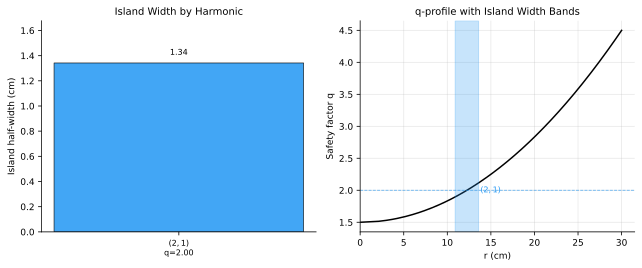

In [7]:
fig_iw, (ax_bar, ax_q) = plt.subplots(1, 2, figsize=(9, 3.8))

# ── (a) Island width bar chart ───────────────────────────────────────────
labels = [f'$({c.m},{c.n})$\nq={c.q_res:.2f}' for c in components]
widths_cm = [c.half_width_r * 100 for c in components]
colors_bar = [ISLAND_CMAPS[(c.harmonic_order - 1) % len(ISLAND_CMAPS)] for c in components]

x_pos = np.arange(len(components))
bars = ax_bar.bar(x_pos, widths_cm, color=colors_bar, edgecolor='k',
                  linewidth=0.7, alpha=0.85, width=0.55)
for bar, w in zip(bars, widths_cm):
    ax_bar.text(bar.get_x() + bar.get_width()/2, w + 0.05,
                f'{w:.2f}', ha='center', va='bottom', fontsize=8)

ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(labels, fontsize=8)
ax_bar.set_ylabel('Island half-width (cm)')
ax_bar.set_title('Island Width by Harmonic')
ax_bar.set_ylim(0, max(widths_cm)*1.25 if widths_cm else 1)

# ── (b) q-profile with island width bands ───────────────────────────────
psi_arr = np.linspace(0, 1, 200)
r_arr = np.sqrt(psi_arr) * eq.r0
q_arr = eq.q_of_psi(psi_arr)

ax_q.plot(r_arr * 100, q_arr, 'k-', linewidth=1.5, label='q(r)')
ax_q.set_xlabel('r (cm)')
ax_q.set_ylabel('Safety factor q')
ax_q.set_title('q-profile with Island Width Bands')

# Draw horizontal bands for each resonance
chirikov_pairs = []
for c in components:
    color = ISLAND_CMAPS[(c.harmonic_order - 1) % len(ISLAND_CMAPS)]
    r_res = np.sqrt(c.psi_res) * eq.r0 * 100  # cm
    w_r = c.half_width_r * 100  # cm
    q_res = c.q_res
    # Island band in r
    ax_q.axvspan(r_res - w_r, r_res + w_r, alpha=0.25, color=color, zorder=2)
    ax_q.axhline(q_res, color=color, lw=0.8, linestyle='--', alpha=0.7)
    ax_q.text(r_res + w_r + 0.2, q_res, f'$({c.m},{c.n})$',
              color=color, fontsize=8, va='center')
    chirikov_pairs.append((r_res, w_r))

# Chirikov overlap
if len(chirikov_pairs) >= 2:
    for i in range(len(chirikov_pairs) - 1):
        r1, w1 = chirikov_pairs[i]
        r2, w2 = chirikov_pairs[i+1]
        gap = abs(r2 - r1)
        sigma = (w1 + w2) / gap if gap > 0 else float('inf')
        print(f'Chirikov sigma between ({components[i].m},{components[i].n}) and ({components[i+1].m},{components[i+1].n}): {sigma:.3f}')

ax_q.set_xlim(0, eq.r0 * 100 * 1.05)
ax_q.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## [MN_SPECTRUM] 2-D Fourier spectrum heatmap

We compute the full $(m, n)$ Fourier spectrum of the RMP field on the primary resonant surface and display it as a heatmap. The resonant mode $(2, -1)$ (and harmonics) should stand out clearly.

Computing (m,n) spectrum on q=2 surface (psi=0.167), n_theta=32, n_phi=32...
Spectrum shape: (13, 9)


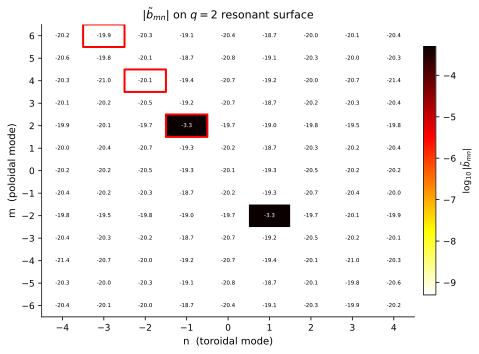

In [8]:
psi_res_21 = eq.resonant_psi(2, 1)[0]
print(f'Computing (m,n) spectrum on q=2 surface (psi={psi_res_21:.3f}), n_theta=32, n_phi=32...')
b_mn = compute_mn_spectrum(
    delta_B_RMP,
    S=psi_res_21,
    equilibrium=eq,
    m_max=6,
    n_max=4,
    n_theta=32,
    n_phi=32,
)
print(f'Spectrum shape: {b_mn.shape}')

fig_sp, ax_sp = plt.subplots(figsize=(7, 5))
plot_mn_heatmap(
    b_mn, m_max=6, n_max=4,
    ax=ax_sp,
    log_scale=True,
    title=r'$|\tilde{b}_{mn}|$ on $q=2$ resonant surface',
    cmap='hot_r',
    highlight_modes=[(2, -1), (4, -2), (6, -3)],
)
plt.tight_layout()
plt.show()


## [PUBLICATION_FIGURE] Multi-phi 6-panel figure

The same section helper scales to a compact multi-section layout.  The O/X markers and local stable branches rotate with toroidal angle, while the PEST-style grid keeps the coordinate meaning visible in every panel.


Saved publication figure to pyna_output/rmp_resonance_publication.png


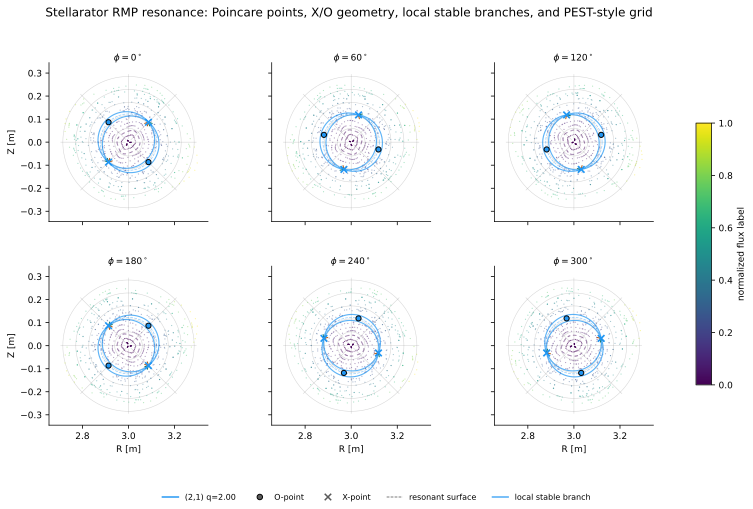

In [9]:
fig_pub, axes_pub = plot_rmp_resonance_sections(
    all_sections_data,
    phi_sections,
    eq=eq,
    components=components,
    colors=ISLAND_CMAPS,
    ncols=3,
    figsize=(12.0, 7.0),
    point_size=1.6,
    point_alpha=0.42,
    title=(
        'Stellarator RMP resonance: Poincare points, X/O geometry, '
        'local stable branches, and PEST-style grid'
    ),
)

out_path = pathlib.Path('pyna_output/rmp_resonance_publication.png')
out_path.parent.mkdir(exist_ok=True)
fig_pub.savefig(str(out_path), dpi=170, bbox_inches='tight', facecolor='white')
print(f'Saved publication figure to {out_path}')
from IPython.display import display
display(fig_pub)
plt.close(fig_pub)
